# <font color="red"> Cuaderno 4. Redes densas </font>

## <font color="blue"> Por Alfredo Alfredo Diaz </font>



## <font color="blue"> TEORIA: Funciones de Activación en Redes Neuronales

![imagen](https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/funcion%20de%20activacion.jpeg)

Las funciones de activación introducen **no linealidad** en una red neuronal, permitiendo modelar relaciones complejas entre variables.

>  Nota: En esta sección **no se incluye la función escalonada**, ya que fue vista en una sesión anterior. Además, no es recomendable usar la función **linear en todas las capas ocultas**, pues la red perdería capacidad no lineal y se comportaría como un modelo lineal.



## 1️ ReLU (Rectified Linear Unit)

$$f(x) = \max(0, x)$$

- Rango: [0, ∞)
- Muy eficiente computacionalmente.
- Reduce el problema del *vanishing gradient*.

 **Uso recomendado:**
- Capas ocultas en la mayoría de redes profundas.



## 2️ Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- Rango: (0,1)
- Interpretable como probabilidad.

 **Uso recomendado:**
- Capa de salida en **clasificación binaria**.

 Puede sufrir *vanishing gradient*.



## 3️ Tanh (Tangente Hiperbólica)

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

- Rango: (-1,1)
- Centrada en cero.
- Gradientes más fuertes que sigmoid cerca del origen.

 **Uso recomendado:**
- Capas ocultas cuando los datos están centrados en 0.
- Redes recurrentes clásicas (RNN).

 También puede presentar *vanishing gradient*.



## 4️ Linear (Identidad)

$$f(x) = x$$

- No introduce no linealidad.
- Derivada constante igual a 1.

 **Uso recomendado:**
- Capa de salida en problemas de **regresión**.

 No se recomienda usar función linear en todas las capas ocultas, porque:
Si todas las capas son lineales, múltiples capas equivalen a una sola transformación lineal.



## 5️ Softmax

$$Softmax(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

- Convierte valores en probabilidades.
- La suma de las salidas es igual a 1.

 **Uso recomendado:**
- Capa de salida en **clasificación multiclase exclusiva**.



#  Resumen según tipo de problema

## 🔹 Regresión
- Capas ocultas: ReLU o Tanh
- Capa de salida: Linear

## 🔹 Clasificación Binaria
- Capas ocultas: ReLU o Tanh
- Capa de salida: Sigmoid

## 🔹 Clasificación Multiclase (exclusiva)
- Capas ocultas: ReLU
- Capa de salida: Softmax



#  Recomendación práctica

- Use **ReLU** como opción por defecto en capas ocultas.
- Use **Tanh** cuando los datos estén centrados.
- Use **Linear solo en la salida de regresión**.
- No combine múltiples capas ocultas lineales consecutivas.



#Modelo de Red Neuronal con una Capa entrada y una de salida


#  Funciones de Pérdida en Redes Neuronales

Aunque las funciones de pérdida ya fueron introducidas anteriormente, aquí reforzamos su papel dentro del entrenamiento de redes neuronales y su relación con los distintos tipos de problemas.


# 1️ ¿Qué es una Función de Pérdida?

Una **función de pérdida (Loss Function)** mide qué tan diferente es la predicción del modelo respecto al valor real.

Formalmente:

$$Loss = L(y_{real}, y_{pred})$$

Durante el entrenamiento:

- La red genera una predicción.
- Se calcula la pérdida.
- Se ajustan los pesos usando backpropagation para minimizar esa pérdida.

En resumen:
> La función de pérdida guía el aprendizaje del modelo.


# 2. Ejemplo Intuitivo

Supongamos un problema de regresión:

- Valor real: 100
- Predicción del modelo: 90

El error es 10.

Dependiendo de la función de pérdida:

- Puede elevarse al cuadrado (MSE)
- Puede tomarse valor absoluto (MAE)
- Puede transformarse logarítmicamente (Cross-Entropy)

Cada función penaliza los errores de manera diferente.




# 3️ Tipos de Funciones de Pérdida según el Problema



## <font color="red"> A. Regresión </font>

Se utilizan cuando la variable objetivo es continua.


## <font color="blue"> 1️ Mean Squared Error (MSE) </font>

$$SE = \frac{1}{n} \sum (y_{real} - y_{pred})^2$$

- Penaliza fuertemente errores grandes.
- Sensible a outliers.
- Muy usada en problemas de regresión.

En TensorFlow:

```python
loss='mse'
```


```python
tf.keras.losses.MeanSquaredError()
```



## <font color="blue"> 2️ Mean Absolute Error (MAE) </font>

$$MAE = \frac{1}{n} \sum |y_{real} - y_{pred}|$$

- Menos sensible a valores atípicos.
- Interpretación directa del error promedio.

En TensorFlow:

```python
loss='mae'
```

o

```python
tf.keras.losses.MeanAbsoluteError()
```

---

 En problemas de regresión:

- Capa de salida: **Linear**
- Funciones de pérdida recomendadas: **MSE o MAE**


## <font color="red"> B. Clasificación Binaria </font>

Cuando la variable objetivo tiene dos clases (0 o 1).

## Binary Crossentropy


Loss = -[y \log(p) + (1-y)\log(1-p)]

- Mide la diferencia entre probabilidades reales y predichas.
- Penaliza con mayor intensidad predicciones incorrectas con alta confianza.
- Es la función estándar en clasificación binaria.

En TensorFlow:

```python
loss='binary_crossentropy'
```

o

```python
tf.keras.losses.BinaryCrossentropy()
```

Configuración típica:

- Capa de salida: 1 neurona
- Activación: Sigmoid
- Pérdida: Binary Crossentropy


## <font color="red"> C. Clasificación Multiclase (Exclusiva)

Cada ejemplo pertenece a una única clase.

### <font color="blue">Categorical Crossentropy </font>

$$Loss = -\sum y_i \log(p_i)$$

Se usa cuando las etiquetas están codificadas en formato **one-hot**.

En TensorFlow:

```python
loss='categorical_crossentropy'
```

o

```python
tf.keras.losses.CategoricalCrossentropy()
```


### <font color="blue">Sparse Categorical Crossentropy </font>

Se usa cuando las etiquetas están en formato entero (0, 1, 2, ...).

En TensorFlow:

```python
loss='sparse_categorical_crossentropy'
```

o

```python
tf.keras.losses.SparseCategoricalCrossentropy()
```

Configuración típica:

- Capa de salida: N neuronas (una por clase)
- Activación: Softmax
- Pérdida: Categorical o Sparse Categorical Crossentropy


### <font color="blue">  Resumen General </font>

| Tipo de Problema | Activación de Salida | Función de Pérdida |
|------------------|---------------------|--------------------|
| Regresión | Linear | MSE / MAE |
| Clasificación Binaria | Sigmoid | Binary Crossentropy |
| Multiclase (one-hot) | Softmax | Categorical Crossentropy |
| Multiclase (enteros) | Softmax | Sparse Categorical Crossentropy |


# Diferencia entre Función de Pérdida y Métrica

##  Función de Pérdida

- Se usa durante el entrenamiento.
- Es diferenciable.
- Se minimiza mediante backpropagation.
- Determina cómo se actualizan los pesos.

Ejemplo en compilación:

```python
model.compile(optimizer='adam',
              loss='binary_crossentropy')
```


## 🔹 Métrica

- Se usa para evaluar el desempeño.
- No necesariamente es diferenciable.
- No participa directamente en el cálculo del gradiente.
- Es un indicador de rendimiento.

Ejemplos comunes:

- Accuracy
- Precision
- Recall
- AUC

Ejemplo en TensorFlow:

```python
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
```


#  Idea Clave

La función de pérdida optimiza el aprendizaje.  
La métrica evalúa qué tan bien está funcionando el modelo.



#  Nota Importante

Elegir incorrectamente la función de pérdida puede impedir que el modelo aprenda correctamente, incluso si la arquitectura es adecuada.

La función de pérdida debe estar alineada con:

- El tipo de problema
- La función de activación de salida
- La naturaleza de las etiquetas


## <font color="blue">  Activación por Defecto en Keras: Linear

En **Keras (TensorFlow)**, si en una capa `Dense` no se especifica el parámetro `activation`,  
la función de activación por defecto es:

$$f(x) = x$$

Es decir, **activación lineal (linear)**.



##  ¿Qué significa esto?

Si escribimos:

```python
layers.Dense(64)
```

Keras internamente interpreta:

```python
layers.Dense(64, activation='linear')
```

La función `linear` simplemente devuelve el valor calculado por la combinación lineal:

$$z = Wx + b$$

Sin aplicar ninguna transformación no lineal.


#  ¿Por qué esto puede ser un problema?

Si todas las capas ocultas usan activación lineal:

$$f(x) = W_3(W_2(W_1x))$$

Toda la red se reduce a una sola transformación lineal equivalente.

 Múltiples capas lineales = una sola capa lineal.

Esto significa que:

- La red **no puede aprender relaciones no lineales**.
- Se pierde la ventaja de usar múltiples capas.
- El modelo se comporta como una regresión lineal (aunque tenga muchas capas).


#  ¿Cuándo es correcto usar linear?

En la **capa de salida para regresión**.

Ejemplo correcto:

```python
layers.Dense(1, activation='linear')
```

 No es recomendable usar `linear` en todas las capas ocultas.


#  Ejemplo Comparativo

##  Modelo incorrecto (sin activaciones ocultas)

```python
model = tf.keras.Sequential([
    layers.Dense(64, input_shape=(20,)),  # linear implícito
    layers.Dense(32),                     # linear implícito
    layers.Dense(1)
])
```

Este modelo es equivalente a una sola transformación lineal.


##  Modelo recomendado

```python
model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])
```

Aquí sí hay no linealidad en las capas ocultas.


#  Idea Clave

Las funciones de activación no lineales son las que permiten que las redes profundas aprendan patrones complejos.

Si no se especifica activación en Keras:

- Se usa `linear` por defecto.  
- Y eso puede limitar severamente la capacidad del modelo.



## <font color="blue"> Batch y Tamaño de Capas en Redes Neuronales </font>

En esta sección presentamos una explicación básica sobre el concepto de **batch** y el diseño de **capas ocultas**.  
 Estos temas se profundizarán más adelante en el curso.



# 1️ ¿Qué es un Batch?

Un **batch** es el número de muestras que la red procesa antes de actualizar los pesos.

En lugar de usar todo el dataset al mismo tiempo (Batch Gradient Descent) o una sola muestra (Stochastic Gradient Descent), normalmente se usa un punto intermedio:

 **Mini-batch Gradient Descent**

Si tenemos 10.000 datos y un batch_size = 32:

$$\frac{10000}{32} \approx 312 \text{ actualizaciones por época}$$



##  ¿Por qué usar batches?

- Reduce uso de memoria.
- Hace el entrenamiento más estable.
- Permite paralelización en GPU.
- Introduce cierto "ruido" útil para escapar de mínimos locales.



##  Tamaños de Batch Recomendados

No existe un valor único ideal, pero comúnmente:

- 16
- 32
- 64
- 128

 Reglas prácticas:

- Si el dataset es pequeño → batch pequeño.
- Si hay mucha memoria GPU → batch mayor.
- Batch muy grande puede generalizar peor.
- Batch muy pequeño puede hacer entrenamiento inestable.

En TensorFlow:

```python
model.fit(X_train, y_train, epochs=50, batch_size=32)
```



# 2️ Tamaño de Capas Ocultas

Las capas ocultas determinan la capacidad del modelo para aprender patrones complejos.

## 🔹 ¿Cuántas neuronas usar?

No existe fórmula exacta, pero recomendaciones comunes:

- Entre el tamaño de la entrada y la salida.
- Potencias de 2 (32, 64, 128, 256).
- Comenzar simple y aumentar si hay underfitting.



# 3️ ¿Conviene ir reduciendo neuronas en capas profundas?

En muchos diseños, sí.

Ejemplo típico:

128 → 64 → 32 → salida

¿Por qué?

- Obliga a la red a comprimir información.
- Reduce sobreajuste.
- Actúa como embudo de características (feature compression).

Pero  no es una regla obligatoria.
Algunas arquitecturas mantienen el mismo tamaño en varias capas.


# 4️ Ejemplo Sencillo

```python
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=32)
```


# Ideas Clave

- Batch controla cuántos datos se procesan antes de actualizar pesos.
- 32 o 64 suelen ser buenos puntos de inicio.
- No existe tamaño "perfecto" de capa oculta.
- Reducir neuronas progresivamente suele ser buena práctica.
- El diseño depende del problema y la cantidad de datos.





# <font color="blue">  Datos de Entrenamiento, Validación y Prueba en Redes Neuronales </font>

Para que un modelo de red neuronal generalice correctamente, los datos deben dividirse en tres conjuntos:

- **Train (Entrenamiento)**
- **Validation (Validación)**
- **Test (Prueba)**

Cada uno cumple un propósito diferente.



# 1️ Datos de Entrenamiento (Train)

Son los datos que el modelo usa para:

- Aprender los patrones.
- Ajustar los pesos mediante backpropagation.
- Minimizar la función de pérdida.

 Aquí ocurre el aprendizaje.

Si solo evaluamos el modelo con estos datos, no sabemos si generaliza correctamente.



# 2️ Datos de Validación (Validation)

Se usan durante el entrenamiento para:

- Evaluar el modelo en datos no vistos.
- Ajustar hiperparámetros.
- Detectar sobreajuste.
- Aplicar Early Stopping.

 Importante:

El modelo **NO aprende directamente de estos datos**, pero sí los utiliza indirectamente para tomar decisiones como:

- Cuántas épocas entrenar.
- Qué arquitectura elegir.
- Qué tasa de aprendizaje usar.

 La validación ayuda a elegir el mejor modelo.


# 3️ Datos de Prueba (Test)

Se utilizan al final del proceso para:

- Evaluar el desempeño final.
- Medir la capacidad real de generalización.
- Simular datos completamente nuevos.

 El conjunto de prueba no debe usarse para ajustar el modelo.

Si se usa repetidamente para tomar decisiones, deja de ser un verdadero test.



#  Flujo Correcto

1. Entrenar con Train.
2. Ajustar con Validation.
3. Evaluar definitivamente con Test.



#  ¿Qué Implica la Validación?

Durante la validación:

- Se calcula `val_loss`.
- Se calculan métricas como `val_accuracy`.
- Se monitorea el comportamiento del modelo.
- Se pueden aplicar callbacks como EarlyStopping.

Ejemplo en Keras:

```python
model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=50,
          batch_size=32)
```

O usando un porcentaje automático:

```python
model.fit(X_train, y_train,
          validation_split=0.2,
          epochs=50)
```



#  ¿Qué Porcentajes se Recomiendan?

No existe una regla universal, pero comúnmente:

## 🔹 Dataset grande
- 70% Train
- 15% Validation
- 15% Test

## 🔹 Dataset mediano
- 70% Train
- 20% Validation
- 10% Test

## 🔹 Dataset pequeño
- 80% Train
- 10% Validation
- 10% Test

O incluso usar validación cruzada.



#  Validación Cruzada (Cross Validation)

Cuando el dataset es pequeño, puede usarse:

- K-Fold Cross Validation

El dataset se divide en K partes.
Se entrena K veces cambiando la partición de validación.

Ventaja:
- Evaluación más robusta.
- Menor dependencia de una sola división.

Desventaja:
- Mayor costo computacional.


#  Recomendaciones Importantes

- No mezclar datos de test en el entrenamiento.
- No ajustar hiperparámetros usando el test.
- Asegurar que la división sea aleatoria.
- En series temporales, no mezclar datos futuros con pasados.


#  Diferencia Conceptual Clave

| Conjunto | ¿Aprende de él? | ¿Ajusta hiperparámetros? | ¿Evalúa desempeño final? |
|-----------|----------------|--------------------------|---------------------------|
| Train     | Sí             | No                       | No                        |
| Validation| No (directo)   | Sí                       | No                        |
| Test      | No             | No                       | Sí                        |

-

# Idea Final

- Train entrena.
- Validation ajusta.
- Test evalúa.

Un modelo que funciona bien en Train pero mal en Test:
 No generaliza.


## <font color="blue"> ¿Cómo Detectar Sobreajuste (Overfitting) en una Red Neuronal? </font>

El **sobreajuste (overfitting)** ocurre cuando el modelo aprende demasiado bien los datos de entrenamiento, incluyendo ruido y patrones irrelevantes, y pierde capacidad de generalización.


# 1️ ¿Cómo Validarlo con Métricas?

Durante el entrenamiento normalmente se monitorean:

- Pérdida de entrenamiento (`loss`)
- Pérdida de validación (`val_loss`)
- Métrica de entrenamiento (`accuracy`, etc.)
- Métrica de validación (`val_accuracy`, etc.)


##  Señales de Sobreajuste

###  Caso típico:

-  `loss` de entrenamiento sigue bajando
-  `val_loss` comienza a subir
-  Diferencia creciente entre entrenamiento y validación

Ejemplo conceptual:

| Época | Loss Train | Loss Val |
|--------|------------|----------|
| 5      | 0.40       | 0.42     |
| 10     | 0.30       | 0.35     |
| 15     | 0.20       | 0.50 ⬆ |

Aquí el modelo empieza a memorizar el entrenamiento.



##  En métricas como Accuracy

Puede observarse:

- Accuracy entrenamiento → 98%
- Accuracy validación → 82%

Brecha grande = posible sobreajuste.


# 2️ ¿Cómo Validarlo en la Gráfica?

En la gráfica típica de entrenamiento:

- Curva de entrenamiento baja progresivamente.
- Curva de validación baja al inicio.
- Luego la curva de validación empieza a subir.

Forma característica:

![imagen](https://fouryears.eu/wp-content/uploads/2017/12/early_stopping.png)


El punto donde `val_loss` empieza a subir es el inicio del sobreajuste.



# 3️ ¿Por Qué Ocurre?

- Modelo demasiado complejo.
- Muchas neuronas o capas.
- Pocos datos.
- Demasiadas épocas.
- Ausencia de regularización.



# 4️ ¿Qué Debo Hacer?

##  1. Early Stopping

Detener entrenamiento cuando la validación empeora.

```python
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
```

---

##  2. Regularización L2

```python
layers.Dense(64, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.01))
```



##  3. Dropout

```python
layers.Dropout(0.5)
```

Reduce dependencia entre neuronas.



##  4. Reducir Complejidad del Modelo

- Menos capas.
- Menos neuronas.
- Arquitectura más simple.


##  5. Más Datos o Data Augmentation

Más datos mejora generalización.



#  Idea Clave

Overfitting ocurre cuando:

- El modelo aprende el entrenamiento.
- Pero falla en generalizar.

Se detecta cuando:

$$Loss_{train} ↓ \quad y \quad Loss_{val} ↑$$




#  Recordatorio Conceptual

- Bajo error en entrenamiento ≠ buen modelo.
- Lo importante es el desempeño en datos no vistos.



# Early Stopping en TensorFlow (Keras)

##  ¿Qué es Early Stopping?

**Early Stopping** es una técnica que detiene el entrenamiento automáticamente cuando el modelo deja de mejorar en el conjunto de validación.

Se utiliza principalmente para:

- Evitar sobreajuste (overfitting).
- Reducir tiempo de entrenamiento.
- Conservar el mejor modelo encontrado.



#  ¿Cómo Funciona?

Durante el entrenamiento se monitorea una métrica (usualmente `val_loss`).

Si la métrica no mejora después de cierto número de épocas consecutivas, el entrenamiento se detiene.



#  Parámetros Importantes

En TensorFlow se implementa con:

```python
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    mode='min'
)
```



##  Explicación de Parámetros

###  monitor
Qué métrica observar.

Ejemplos:
- `'val_loss'`
- `'val_accuracy'`

Recomendación:
 En la mayoría de los casos usar `val_loss`.



###  patience
Número de épocas a esperar sin mejora antes de detener.

Ejemplo:
- patience=5 → espera 5 épocas sin mejora antes de parar.

Recomendación:
- 3–10 para datasets medianos.
- Más alto si el dataset es ruidoso.


###  min_delta
Mejora mínima para considerar que hubo progreso.

Ejemplo:
- min_delta=0.001 → si mejora menos que eso, no se considera mejora real.

Recomendación:
- Útil cuando la curva oscila ligeramente.



###  restore_best_weights
Si es `True`, al detenerse el entrenamiento se restauran los pesos de la mejor época.

Recomendación:
 Siempre usar `True` en producción.



### 🔹 mode
- `'min'` → cuando se quiere minimizar (ej. val_loss).
- `'max'` → cuando se quiere maximizar (ej. val_accuracy).

Generalmente:
- Para pérdida → `'min'`
- Para accuracy → `'max'`



# Ejemplo Completo

```python
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


#  ¿Qué Ocurre Internamente?

Si la `val_loss` deja de mejorar:

```
Epoch 15 → Mejor val_loss
Epoch 16 → No mejora
Epoch 17 → No mejora
Epoch 18 → No mejora
Epoch 19 → No mejora
Epoch 20 → No mejora
→ Se detiene (patience=5)
```

El modelo vuelve a los pesos de la época 15.



#  Recomendaciones para el Científico de Datos

- Siempre monitorear `val_loss` en problemas estándar.  
- Usar `restore_best_weights=True`.  
- No usar paciencia demasiado baja (evita detener demasiado pronto).  
- Combinar con reducción de tasa de aprendizaje (`ReduceLROnPlateau`).  
- Analizar siempre la gráfica de entrenamiento.

---

#  Buenas Prácticas

- No depender únicamente de EarlyStopping.
- Revisar si hay underfitting antes de reducir épocas.
- Validar que el conjunto de validación sea representativo.
- Evitar data leakage.



#  Idea Clave

EarlyStopping no mejora el modelo por sí mismo.

Su función es:
- Evitar sobreentrenamiento.
- Conservar el mejor punto de generalización.


En próximas sesiones profundizaremos en:
- Bias vs Variance
- Curvas de aprendizaje
- Regularización avanzada
- Batch Normalization
- Técnicas modernas de generalización
- Ajuste fino de hiperparámetros
- Formatos de persistencia
- Data leakage
- Validación cruzada avanzada
- Time series split
- Estrategias en datasets desbalanceados
- Learning Rate Scheduling
- ReduceLROnPlateau
- ModelCheckpoint
- Estrategias avanzadas de entrenamiento

# <font color="blue">  PRACTICA <font>

Este taller tipico de clasificación te ayudará a explicar el concepto de redes neuronales profundas, en donde más de una capa es necesaria para resolver un problema no linealmente separable, como en el caso de los círculos concéntricos que estás utilizando en este ejemplo.

**Descripción del Taller:**

* Objetivo: Mostrar cómo un problema no lineal (clasificación de dos círculos concéntricos, donde el primer circulo pertenece a una clase y el externo a otra clase. Ver imagen) requiere múltiples capas (redes neuronales profundas) para ser resuelto correctamente. Realice la evaluación del modelo, prediga con datos sintéticos y realice la visualización del mapa de predicción para el modelo de una capa. Dale persistencia al modelo.

* Enfoque: En este cuarderno primero, haremos  un modelo simple con una sola capa, luego se amplía a un modelo más complejo con más capas, y se comparan los resultados.



 # Generación de los datos artificiales
 En esta celda se generan los datos con make_circles, que crea dos clases de puntos distribuidos en dos círculos concéntricos, un problema que no puede ser resuelto de manera lineal.

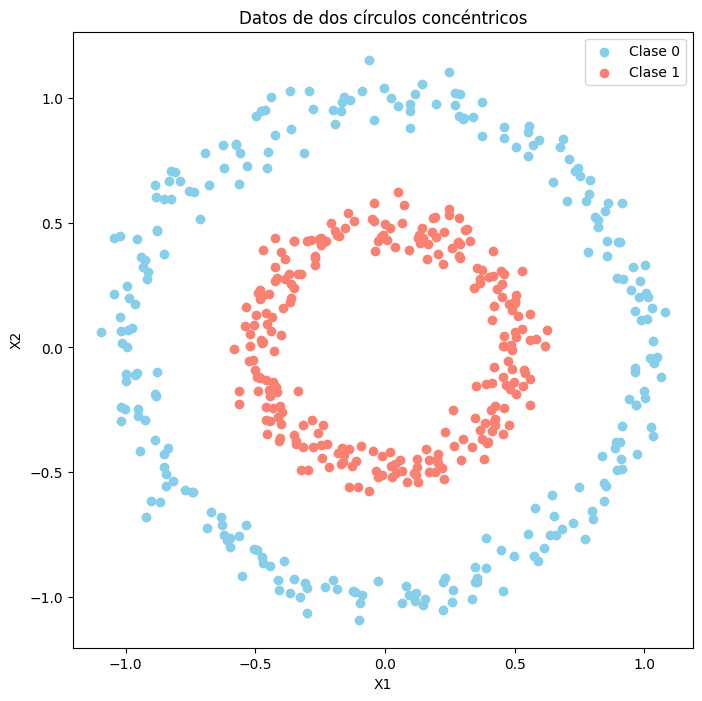

In [ ]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Set the seed for reproducibility
np.random.seed(42)

# Creamos nuestros datos artificiales (dos círculos concéntricos)
X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

# Visualización de los datos generados
plt.figure(figsize=(8, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


In [ ]:
# Crear el DataFrame
df = pd.DataFrame(X, columns=['X1', 'X2'])  # Columnas X1 y X2 para las características
df['Y'] = Y  # Añadimos la columna de etiquetas Y

# Mostramos las primeras filas del DataFrame
df.head()

#Este paso no es necesario, ya que podemos trabajar con los arreglos directamente

,X1,X2,Y
0,-0.469276,0.210118,1
1,-0.164164,0.986075,0
2,-0.471454,0.019974,1
3,-0.670347,-0.657977,0
4,-0.826468,0.594071,0


In [ ]:
df.shape

(500, 3)

In [ ]:
# Importamos las librerías de Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Creamos el modelo con una sola capa
model_single_layer = Sequential([
    Input(shape=(2,)),  # Define explícitamente la forma de entrada como 2 características
    Dense(1, activation='sigmoid')  # Capa de salida con 1 neurona
])

#Se usa un sola nuerona porque como solo son dos clases [0,1] se requiere una sola neurona para clasficar ese valor.


In [ ]:
model_single_layer.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X,Y

(array([[-4.69276248e-01,  2.10118226e-01],
        [-1.64164375e-01,  9.86075381e-01],
        [-4.71453676e-01,  1.99741343e-02],
        [-6.70346838e-01, -6.57977105e-01],
        [-8.26468133e-01,  5.94071043e-01],
        [-4.32719009e-01, -2.43338043e-01],
        [-4.77054011e-01,  3.16899568e-02],
        [-9.74612851e-01,  7.81620244e-02],
        [-1.71239032e-01,  9.47057214e-01],
        [ 1.27256616e-01, -5.38897373e-01],
        [ 9.80041852e-01,  2.02769492e-01],
        [ 2.24147733e-01, -1.05124716e+00],
        [-2.78021705e-01, -4.00385002e-01],
        [-5.76351076e-01,  8.16294090e-01],
        [-3.99911504e-01,  4.81766006e-02],
        [-4.47077377e-01, -1.69666392e-01],
        [ 4.91553419e-01, -8.79606194e-02],
        [ 7.31505825e-01,  7.09277101e-01],
        [ 3.99896772e-02,  4.04343361e-01],
        [-2.57125389e-01, -3.42358537e-01],
        [ 4.65903441e-01, -1.51731118e-01],
        [ 5.39447219e-01, -1.00686454e-01],
        [ 2.87781058e-01,  3.604

In [ ]:
#Calcular el numero de batch en el entreamiento
len(X)/32

15.625

In [ ]:
X.shape

(500, 2)

In [ ]:

# Compilamos el modelo
model_single_layer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


#optimizador="adam"
#tasa_aprendizaje=0.03
#model_single_layer.compile(optimizer=optimzador, learning_rate=tasa_aprendizaje, loss='binary_crossentropy', metrics=['accuracy'])

historia= model_single_layer.fit(X, Y, epochs=100, batch_size=32, verbose=True)

#Cuantos lotes se ejecutan en cada epoca = 16 = int(500/32), int(tamaño del dataset/tamaño de lotes)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5178 - loss: 0.7785
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4993 - loss: 0.7712 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4864 - loss: 0.7797 
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4744 - loss: 0.8016 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4975 - loss: 0.7713 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4799 - loss: 0.7896 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4942 - loss: 0.7695 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4989 - loss: 0.7638 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4951 - loss: 0.7755 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5254 - loss: 0.7591 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5130 - loss: 0.7552 
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

In [ ]:
# Evaluamos el modelo
perdidas, accuracy = model_single_layer.evaluate(X, Y, verbose=True)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4658 - loss: 0.7029


In [ ]:
perdidas, accuracy

(0.6975396871566772, 0.49799999594688416)

In [ ]:
# Assuming 'model_single_layer' is already defined and trained as in the provided code.
prediction = model_single_layer.predict(np.array([[-0.7, -0.5],[-0.9,0.5],[-0.5,0.1],[0.4,0.4],[0.7,0.7]]))

#With this point the result have to be equal 1, but the prediction was 0

# Si vas a predecir un solo sample use esto:
#predicted_class = 1 if prediction > 0.5 else 0
#print(f"Prediction probability: {prediction[0][0]}")
#print(f"Predicted class: {predicted_class}")

#Si vas a predecir un conjunto de datos use:
# si en el arreglo prediction el valor es igual a 0.5 entoces ponga un 1, de lo contrario un 0
predicted_class = (prediction > 0.5).astype(int)
print(f"Prediction probability: {prediction}")
print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Prediction probability: [[0.43236074]
 [0.48902312]
 [0.4819324 ]
 [0.54611933]
 [0.58037204]]
Predicted class: [[0]
 [0]
 [0]
 [1]
 [1]]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


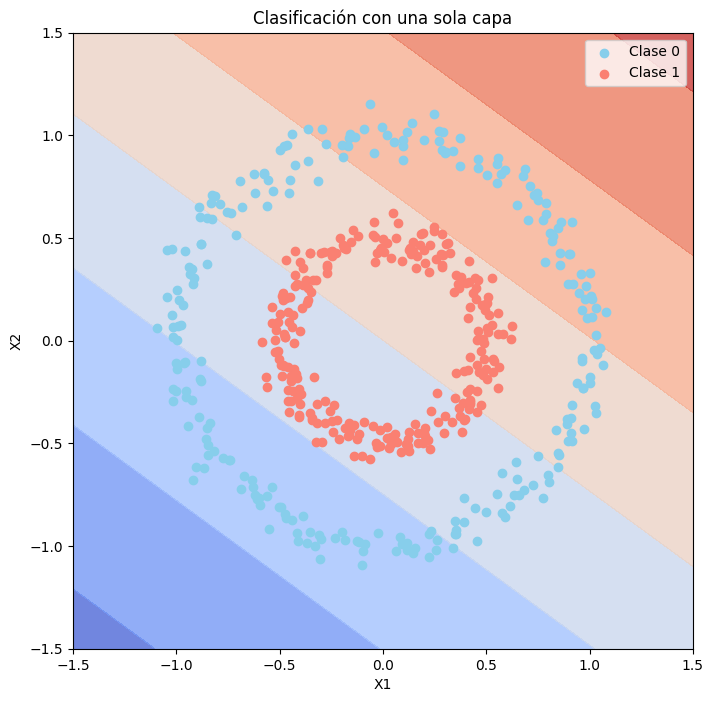

In [ ]:
# Visualización del mapa de predicción para el modelo de una capa
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
predictions = model_single_layer.predict(grid).reshape(xx.shape)

# Visualizamos la clasificación
plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, predictions, cmap="coolwarm", alpha=0.8)
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Clasificación con una sola capa")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

#[[-0.7, -0.5],[-0.9,0.5],[-0.5,0.1],[0.4,0.4],[0.7,0.7]]

In [ ]:
# Imprimir la precisión del modelo
print(f"Exactitud del modelo de una capa: {accuracy:.2f}")


Exactitud del modelo de una capa: 0.50


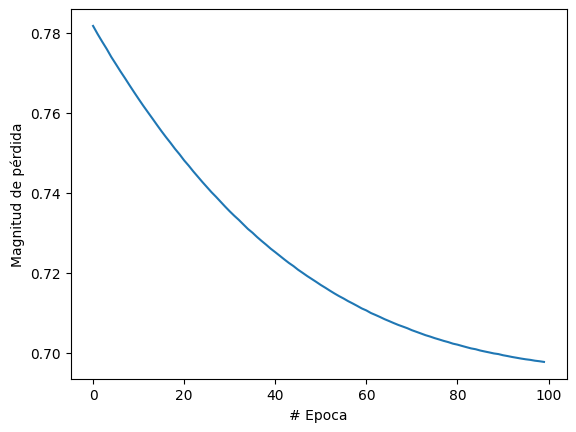

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historia.history["loss"])

##Conclusión: Como el problema no es lineal, una sola capa probablemente no será capaz de separar correctamente las dos clases (círculos).

#Redes Neuronales Densas (modelo de red neuronal con más capas)
En este taller vamos agregar más de una capa es necesaria para resolver un problema no linealmente separable, seguiremos con el ejercicio anterior.


**Descripción del Taller**


Objetivo: Demostrar cómo el problema anterior que no es lineal (clasificación de dos círculos concéntricos) requiere múltiples capas (redes neuronales profundas) para ser resuelto correctamente.


Explicación de las capas: al explicar las redes profundas, es importante mencionar cómo las capas ocultas y las funciones de activación trabajan para transformar el espacio de características de manera que el modelo pueda aprender patrones más complejos.


Aqui la elección de las funciones de activación afecta directamente a cómo el modelo aprende. En este caso, las capas ocultas utilizan **ReLU** porque ayudan a aprender representaciones no lineales, y **sigmoide** en la salida porque estamos trabajando con un problema de clasificación binaria.


In [ ]:
# Creamos el modelo con varias capas
model_deep = Sequential([
    Input(shape=(2,)),  # Capa de entrada con 2 neuronas
    Dense(8, activation='relu'),  # Capa oculta con 8 neuronas
    Dense(4, activation='relu'),                      # Capa oculta con 4 neuronas
    Dense(1, activation='sigmoid')                  # Capa de salida con 1 neurona
])

# Compilamos el modelo
model_deep.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
model_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

Del compile vamos a explicar la función de pérdida aquí usada:

La función de pérdida binary_crossentropy se utiliza comúnmente en problemas de clasificación binaria, donde las salidas del modelo son valores que representan dos clases distintas. En nuestro caso, estamos trabajando con un conjunto de datos generado por make_circles, donde las etiquetas (Y) son binarias: 0 o 1, lo que significa que estamos resolviendo un problema de clasificación binaria.


En un problema de clasificación binaria, la salida del modelo es un valor entre 0 y 1, interpretado como una probabilidad de que un ejemplo pertenezca a una de las dos clases posibles. En otras palabras, la salida del modelo se pasa generalmente por una función de activación sigmoide que convierte el valor de salida en una probabilidad. La función de pérdida binary_crossentropy mide la discrepancia entre estas probabilidades y las etiquetas reales (0 o 1).

In [ ]:
# Entrenamos el modelo con los datos
history_deep = model_deep.fit(X, Y, epochs=500, batch_size=32, verbose=True)

Epoch 1/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4783 - loss: 0.7000
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4753 - loss: 0.6998 
Epoch 3/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4809 - loss: 0.6933 
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4834 - loss: 0.6912 
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4834 - loss: 0.6881 
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4746 - loss: 0.6859 
Epoch 7/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5066 - loss: 0.6801 
Epoch 8/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5237 - loss: 0.6776
Epoch 9/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5292 - loss: 0.6752
Epoch 10/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5007 - loss: 0.6730 
Epoch 11/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5657 - loss: 0.6629
Epoch 12/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - a

In [ ]:
# Evaluamos el modelo
loss_deep, accuracy_deep = model_deep.evaluate(X, Y, verbose=0)
print(loss_deep, accuracy_deep)

0.005079512484371662 1.0


In [ ]:
# Assuming 'model_single_layer' is already defined and trained as in the provided code.
prediction = model_deep.predict(np.array([[-1.0,0.0],[-0.5,-0.4],[-0.3,3],[0,-0.5],[0.8,0.4]]))

# Tomar prediction para ajustar la predicción con un umbral de 0.5
predicted_class = (prediction > 0.5).astype(int)

print(f"Prediction probability: {prediction}")
print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Prediction probability: [[1.3162621e-05]
 [9.8826617e-01]
 [0.0000000e+00]
 [9.9021626e-01]
 [1.6878148e-03]]
Predicted class: [[0]
 [1]
 [0]
 [1]
 [0]]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


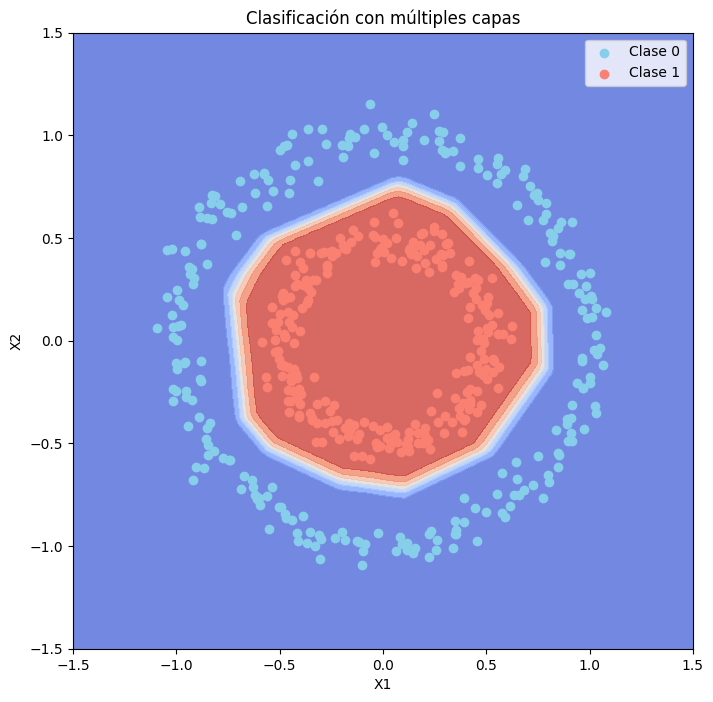

In [ ]:
# Visualización del mapa de predicción para el modelo de varias capas
predictions_deep = model_deep.predict(grid).reshape(xx.shape)

# Visualizamos la clasificación
plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, predictions_deep, cmap="coolwarm", alpha=0.8)
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Clasificación con múltiples capas")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


In [ ]:
# Imprimir la precisión del modelo
print(f"Precisión del modelo con múltiples capas: {accuracy_deep:.2f}")

Precisión del modelo con múltiples capas: 1.00


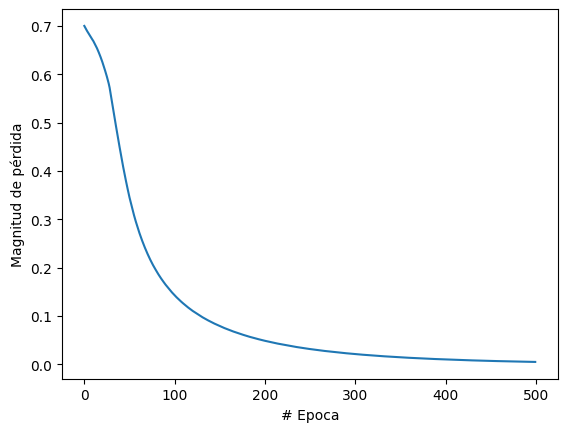

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(history_deep.history["loss"])

# Ajustemos parámetros. Adventencia debes crear el modelo con otro nombre

In [ ]:
# Creamos el modelo con varias capas
model_deep2 = Sequential([
    Input(shape=(2,)),  # Capa de entrada con 2 neuronas
    Dense(8, activation='relu'),  # Capa oculta con 8 neuronas
    Dense(4, activation='relu'),                      # Capa oculta con 4 neuronas
    Dense(1, activation='sigmoid')                  # Capa de salida con 1 neurona
])

# Compilamos el modelo
model_deep2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
model_deep2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# poner early stoping a history_deep = model_deep.fit(X, Y, epochs=500, ,batch_size=32, verbose=True)

from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=5, min_delta=1e-3, restore_best_weights=True)

# Train the model with early stopping
history_deep2 = model_deep2.fit(X, Y, epochs=500, batch_size=32, verbose=True, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.5029 - loss: 0.6723 - val_accuracy: 0.4500 - val_loss: 0.6762
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5218 - loss: 0.6657 - val_accuracy: 0.4500 - val_loss: 0.6734
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5706 - loss: 0.6543 - val_accuracy: 0.4500 - val_loss: 0.6710
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5289 - loss: 0.6546 - val_accuracy: 0.4500 - val_loss: 0.6678
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4934 - loss: 0.6599 - val_accuracy: 0.4500 - val_loss: 0.6647
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4953 - loss: 0.6567 - val_accuracy: 0.4500 - val_loss: 0.6616
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5019 - loss: 0.6505 - val_accuracy: 0.4700 - val_loss: 0.6583
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5883 - loss: 0.6323 - val_accuracy: 0.4700 -

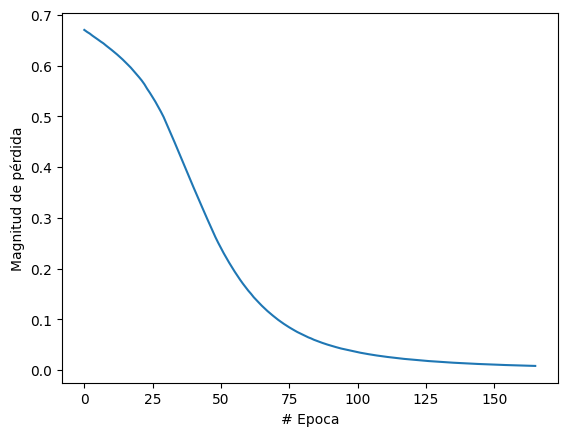

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(history_deep2.history["loss"])

In [ ]:
# recuperar los weight y los bias del modelo con early stoping


# Get the weights and biases for each layer
for i, layer in enumerate(model_deep2.layers):
  weights = layer.get_weights()[0]
  biases = layer.get_weights()[1]
  print(f"Layer {i+1}:")
  print("Weights:")
  print(weights)
  print("Biases:")
  print(biases)
  print("-" * 20)

# Example of accessing weights and biases of a specific layer (e.g., the first hidden layer)
first_hidden_layer_weights = model_deep2.layers[1].get_weights()[0]
first_hidden_layer_biases = model_deep2.layers[1].get_weights()[1]

print("Weights of the first hidden layer:\n", first_hidden_layer_weights)
print("\nBiases of the first hidden layer:\n", first_hidden_layer_biases)

Layer 1:
Weights:
[[-0.68130517  1.6034317   0.19279979  0.80546856  0.46176162 -1.2044499
  -1.5530888   0.82395345]
 [ 1.5973359   0.46053275 -0.30835098  1.5506285  -1.4936479  -0.4141076
  -0.1800963  -0.913465  ]]
Biases:
[-0.39038712 -0.4804178   1.3030217  -0.237292   -0.29199746 -0.30277425
 -0.17154016 -0.06292597]
--------------------
Layer 2:
Weights:
[[ 1.0629617  -0.35545018  1.315999    1.0884708 ]
 [ 0.66394085 -1.0453905   1.298876    1.0476726 ]
 [-0.19139598  1.4745531  -0.65709496 -0.44145483]
 [ 1.0251933  -0.8348518   1.0249149   0.84707844]
 [ 0.990293   -1.2500578   1.4942127   1.3097959 ]
 [ 1.1938275  -1.2242757   1.1198645   1.4681247 ]
 [ 0.71511644 -0.5555662   1.4734211   0.9890976 ]
 [ 1.1223482  -0.42070666  1.5486034   1.3215353 ]]
Biases:
[-0.6100853   1.1969361  -0.34269753 -0.42575264]
--------------------
Layer 3:
Weights:
[[-1.7985477]
 [ 1.8429568]
 [-1.0181041]
 [-1.9937274]]
Biases:
[0.66004467]
--------------------
Weights of the first hidden la

#Conclusión

Este modelo tiene dos capas ocultas con 8 y 4 neuronas y funciones de activación ReLU para las capas ocultas. La capa de salida sigue usando sigmoide.

**Resultado esperado:** Al tener más capas, el modelo ahora es capaz de aprender la estructura no lineal de los círculos concéntricos, lo que debería resultar en una clasificación más precisa.


#Agregar nuevas caracteristicas o features

Podemos mejorar el modelo añadiendo una nueva característica, como $X_1^2$  , a las entradas. Esta transformación no lineal puede ayudar a la red neuronal a capturar patrones más complejos, especialmente en un problema no lineal como los círculos concéntricos.

Es decir vamos a tener $X_1$ , $X_2$ y $(X_1*X_2)^2$ (Ahora serán tres entradas donde una de ellas es la multiplicación de $X_1$ y $X2$ todo elevado al cuadrado  y , llamado truco de kernel polinomial cuando estuvimos estudiando SVM).


In [ ]:
# Crear el DataFrame
df = pd.DataFrame(X, columns=['X1', 'X2'])
df['Y'] = Y

# Añadir la nueva característica X1*x2^2
df['X1X2^2'] = (df['X1']*df['X2']) ** 2


# Visualizamos las primeras filas del DataFrame
df.head()

,X1,X2,Y,X1X2^2
0,-0.469276,0.210118,1,0.009723
1,-0.164164,0.986075,0,0.026205
2,-0.471454,0.019974,1,0.000089
3,-0.670347,-0.657977,0,0.194545
4,-0.826468,0.594071,0,0.241062


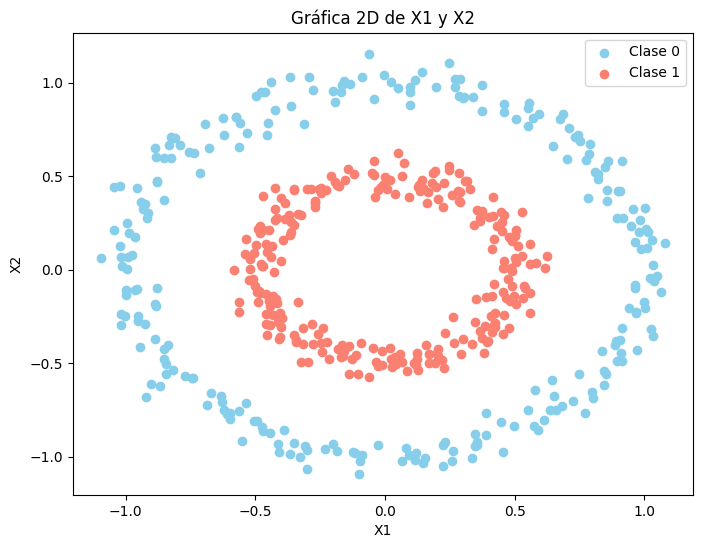

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
# Gráfica 2D (X1, X2)
plt.figure(figsize=(8, 6))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Gráfica 2D de X1 y X2")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

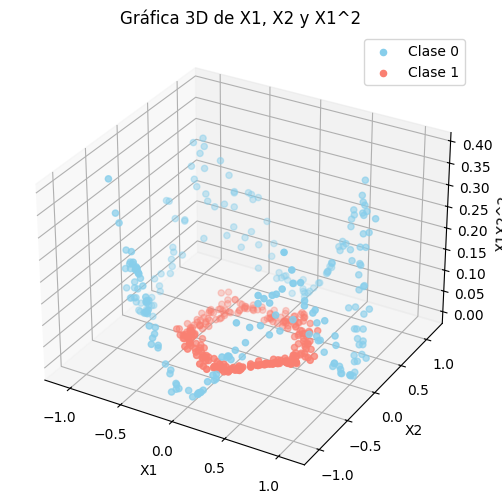

In [ ]:
# Agregar X1^2 como una nueva característica
X_square = np.column_stack([X, (X[:, 0]* X[:, 1])**2])  # Agregar X1^2 a los datos

# Gráfica 3D (X1, X2, X1^2)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Graficar las clases en 3D
ax.scatter(X_square[Y == 0, 0], X_square[Y == 0, 1], X_square[Y == 0, 2], c="skyblue", label="Clase 0")
ax.scatter(X_square[Y == 1, 0], X_square[Y == 1, 1], X_square[Y == 1, 2], c="salmon", label="Clase 1")

# Establecer etiquetas para los ejes
ax.set_title("Gráfica 3D de X1, X2 y X1^2")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X1X2^2")
ax.legend()

plt.show()

In [ ]:
# Seleccionamos las características y etiquetas del DataFrame
X_new = df[['X1', 'X2', 'X1X2^2']].values  # Usamos X1, X2 y X1^2
Y_new = df['Y'].values

In [ ]:
# Creamos el modelo con varias capas
model_deep3 = Sequential([
    Input(shape=(3,)),  # Ahora tenemos 3 características
    Dense(8, activation='relu'),  # Capa oculta con 8 neuronas
    Dense(4, activation='relu'),  # Capa oculta con 4 neuronas
    Dense(1, activation='sigmoid')  # Capa de salida con 1 neurona
])
# Compilamos el modelo
model_deep3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Entrenamos el modelo con los datos
history_deep3 = model_deep3.fit(X_new, Y_new, epochs=300, batch_size=32, verbose=True)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5078 - loss: 0.6996
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5243 - loss: 0.6941 
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5093 - loss: 0.6875 
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5190 - loss: 0.6836 
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5022 - loss: 0.6788 
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5348 - loss: 0.6699 
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5549 - loss: 0.6642 
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5760 - loss: 0.6580 
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5314 - loss: 0.6614 
Epoch 10/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6079 - loss: 0.6483 
Epoch 11/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5631 - loss: 0.6447 
Epoch 12/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

In [ ]:
# Evaluamos el modelo
loss_deep3, accuracy_deep3 = model_deep3.evaluate(X_new, Y_new, verbose=0)

In [ ]:
loss_deep3, accuracy_deep3

(0.0006816299865022302, 1.0)

In [ ]:
# Visualización del mapa de predicción para el modelo de múltiples capas
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_with_new_feature = np.c_[grid, (grid[:, 0]*grid[:, 1]) ** 2]  # Añadimos X1^2 en la grilla de predicción
predictions_deep = model_deep3.predict(grid_with_new_feature).reshape(xx.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


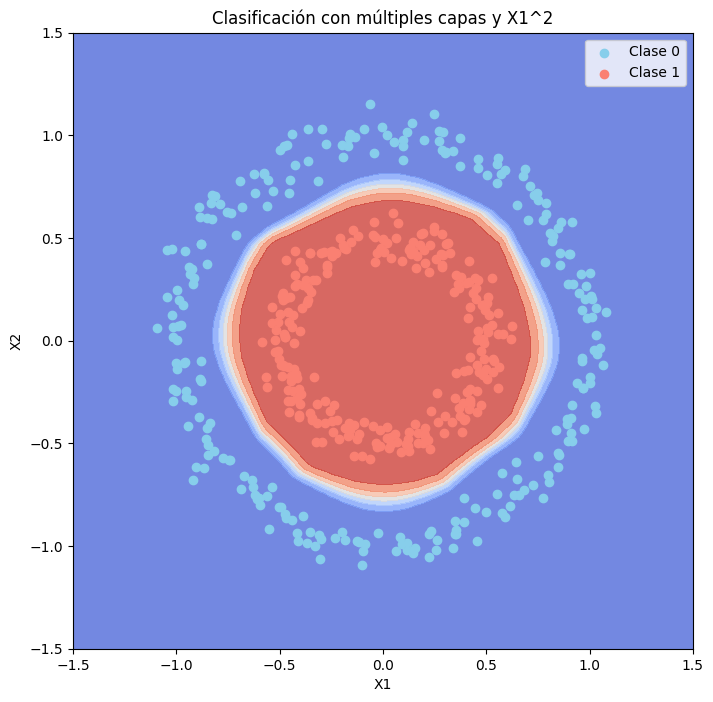

In [ ]:
# Visualizamos la clasificación
plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, predictions_deep, cmap="coolwarm", alpha=0.8)
plt.scatter(X_new[Y_new == 0, 0], X_new[Y_new == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X_new[Y_new == 1, 0], X_new[Y_new == 1, 1], c="salmon", label="Clase 1")
plt.title("Clasificación con múltiples capas y X1^2")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


In [ ]:
# Imprimir la precisión del modelo
print(f"Precisión del modelo con X1X2^2: {accuracy_deep3:.2f}")

Precisión del modelo con X1X2^2: 1.00


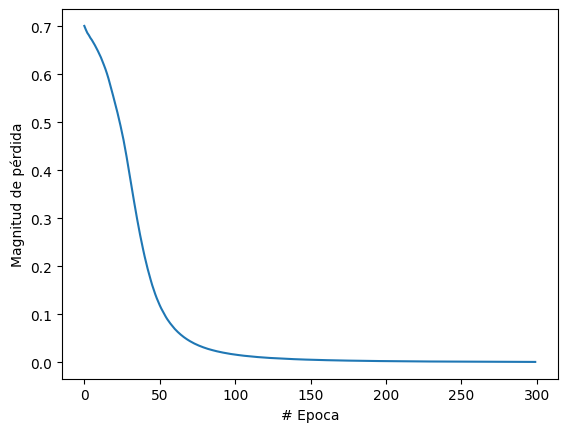

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(history_deep3.history["loss"])

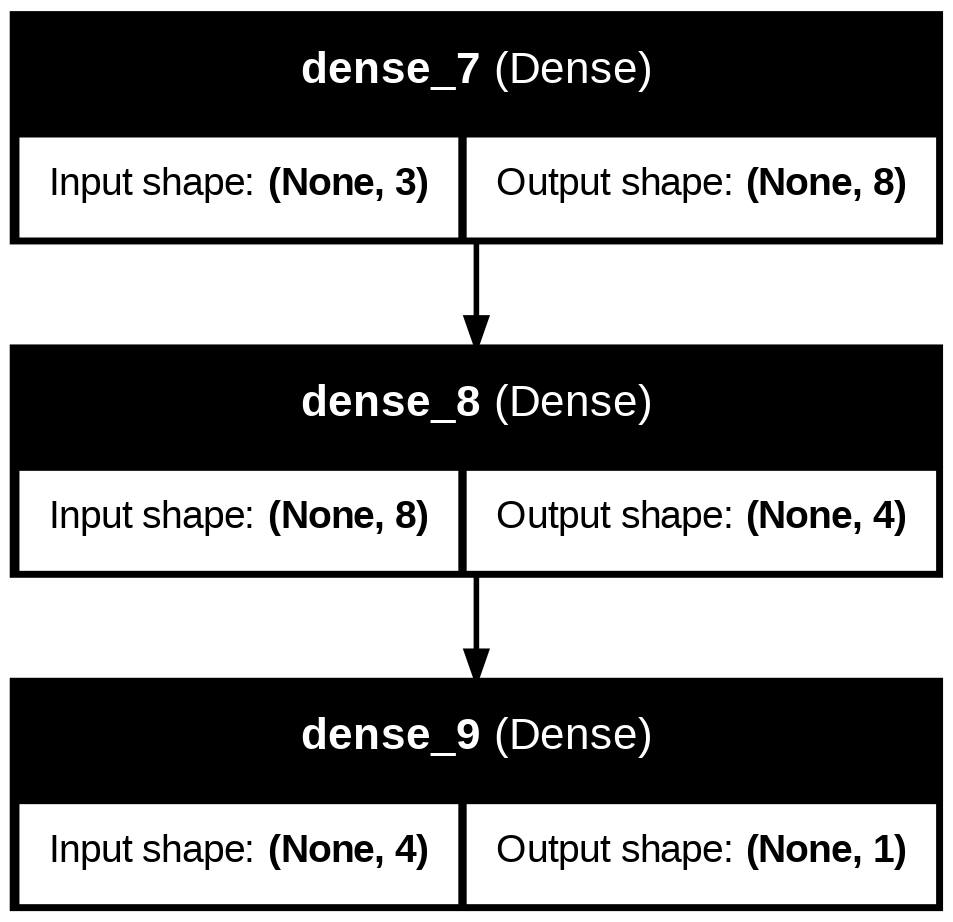

In [ ]:
# Visualizando la red neuronal
from keras.utils import plot_model
# Visualizar el modelo
plot_model(model_deep3, to_file='modelo.png', show_shapes=True, show_layer_names=True)